This script calcautes the lyapunov on strides based on predifined events

Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Resolved file path:        C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\data\PBT\Young\Cereneo_SR_13\Pre\markers.nc
File exists?:              True


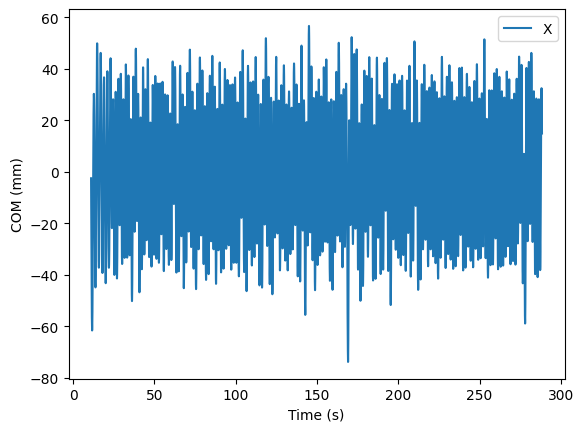

In [84]:
# make sure the path is correctly defined
import argparse
from pathlib import Path
import numpy as np
import xarray as xr
import sys
import os
cwd = Path.cwd()
print("Current working directory:", cwd)
file_path = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_13" /"Pre"/ "markers.nc"
print("Resolved file path:       ", file_path.resolve())
print("File exists?:             ", file_path.exists())
markers= xr.open_dataarray(file_path)
com= markers.sel(channel="COM")
import numpy as np
from scipy.signal import detrend, butter, filtfilt

def preprocess_com(ts: np.ndarray,
                   fs: float = 100.0,
                   low_bp: float = 0.1,
                   high_bp: float = 5.0,
                   low_lp: float = 10.0,
                   do_zscore: bool = False) -> np.ndarray:
    """
    Preprocess a mediolateral COM (in mm) time series.
    
    Steps:
      1) Remove linear trend (detrend).
      2) Apply a gentle low-pass at `low_lp` Hz to remove >10 Hz noise.
      3) Apply a band-pass between `low_bp`–`high_bp` Hz to keep step frequency.
      4) Optionally zero-mean & unit-variance (z-score).
    
    Inputs:
      ts      : 1D np.ndarray of COM_x values in millimeters.
      fs      : Sampling frequency (default 100 Hz).
      low_bp  : Lower cutoff for band-pass (default 0.1 Hz).
      high_bp : Upper cutoff for band-pass (default 5.0 Hz).
      low_lp  : Cutoff for low-pass (default 10.0 Hz).
      do_zscore : If True, z-score the final output.
    
    Returns:
      ts_out  : Preprocessed 1D array, same length as input.
    """
    # 1) Detrend
    ts_dt = detrend(ts)

    # 2) Gentle low-pass at low_lp Hz
    nyq = fs / 2.0
    b_lp, a_lp = butter(N=4, Wn=(low_lp/nyq), btype='low')
    ts_lp = filtfilt(b_lp, a_lp, ts_dt)

    # 3) Band-pass from low_bp to high_bp Hz
    b_bp, a_bp = butter(N=4, Wn=[low_bp/nyq, high_bp/nyq], btype='bandpass')
    ts_bp = filtfilt(b_bp, a_bp, ts_lp)

    # 4) (Optional) Z-score
    if do_zscore:
        ts_out = (ts_bp - np.mean(ts_bp)) / np.std(ts_bp)
    else:
        ts_out = ts_bp

    return ts_out



#select the COM for context="Left", cycle=0
#com0 = com.sel(context="Left", cycle=0)  
#com0 now has dims (axis:3, time:127)

time = com.coords["time"].values       # shape (127,)
x    = com.sel(axis="x").values        # shape (127,)
y    = com.sel(axis="y").values
z    = com.sel(axis="z").values
x= preprocess_com(x)
import matplotlib.pyplot as plt
plt.plot(time, x, label="X")
# plt.plot(time, y, label="Y")
# plt.plot(time, z, label="Z")
plt.xlabel("Time (s)")
plt.ylabel("COM (mm)")
plt.legend()
plt.show()


In [60]:
import numpy as np
import xarray as xr
from pathlib import Path
from scipy.signal import detrend, butter, filtfilt
# 1) Preprocessing: detrend, band‑pass, and z‑score
def preprocess_signal(ts: np.ndarray, fs: float = 100.0,
                      low: float = 0.1, high: float = 3.0) -> np.ndarray:
    """
    Remove linear trend, band‑pass between low–high Hz, then zero‑mean and unit‑variance.
    """
    ts = detrend(ts)
    b, a = butter(4, [low/(fs/2), high/(fs/2)], btype='bandpass')
    ts = filtfilt(b, a, ts)
    return (ts - np.mean(ts)) / np.std(ts)

# 2) Average Mutual Information with quantile bins
def average_mutual_information(ts: np.ndarray, lag: int, bins: int = 64) -> float:
    """
    Compute AMI I(lag) between x(t) and x(t+lag) using equal‑occupancy bins.
    """
    edges = np.quantile(ts, np.linspace(0, 1, bins+1))
    x, y = ts[:-lag], ts[lag:]
    hist2d, _, _ = np.histogram2d(x, y, bins=[edges, edges])
    pxy = hist2d / np.sum(hist2d)
    px = np.sum(pxy, axis=1)
    py = np.sum(pxy, axis=0)
    mask = pxy > 0
    return np.sum(pxy[mask] * np.log(pxy[mask] / (px[:, None] * py[None, :])[mask]))


# 3) Optimal lag: first local minimum of AMI or global minimum fallback
def optimal_lag(ts: np.ndarray, max_lag: int = 200, bins: int = 64) -> int:
    ami_vals = [average_mutual_information(ts, lag, bins) for lag in range(1, max_lag+1)]
    for i in range(1, len(ami_vals)-1):
        if ami_vals[i] < ami_vals[i-1] and ami_vals[i] < ami_vals[i+1]:
            return i+1
    return int(np.argmin(ami_vals) + 1)


# 4) Compute false‑nearest‑neighbors percentage
def compute_fnn_percentage(ts: np.ndarray, lag: int,
                           max_dim: int = 10, rtol: float = 0.15):
    N = len(ts)
    dims = np.arange(1, max_dim+1)
    fnn_perc = np.zeros_like(dims, dtype=float)

    for idx, m in enumerate(dims):
        M = N - m*lag
        if M <= 0:
            fnn_perc[idx:] = np.nan
            break
        # build m‑dimensional delay vectors
        embedded = np.vstack([ts[i*lag : i*lag + M] for i in range(m)]).T
        false = total = 0
        for i in range(M):
            dists = np.linalg.norm(embedded - embedded[i], axis=1)
            dists[i] = np.inf
            dists[max(0, i-m*lag): i+m*lag] = np.inf
            j = np.argmin(dists)
            if dists[j] == np.inf:
                continue
            d_extra = abs(ts[i+m*lag] - ts[j+m*lag])
            if d_extra / dists[j] > rtol:
                false += 1
            total += 1
        fnn_perc[idx] = false / total if total else np.nan

    return dims, fnn_perc





def optimal_embedding_dimension(ts: np.ndarray,
                            lag: int,
                            max_dim: int = 15,
                            rtol: float = 0.15,
                            fnn_threshold: float = 0.10) -> int:
    """
    Return the smallest m where FNN% < fnn_threshold,
    else the 'elbow' where adding dims yields diminishing returns.
    """
    dims, fnn = compute_fnn_percentage(ts, lag, max_dim, rtol)
    # threshold rule
    for m, p in zip(dims, fnn):
        if not np.isnan(p) and p < fnn_threshold:
            return int(m)
    # elbow‐fallback: look for the largest curvature point
    # simple “maximum second‐difference” method
    second_diff = np.diff(fnn, n=2)
    if len(second_diff) > 0:
        elbow = np.argmax(np.abs(second_diff)) + 2
        return int(min(elbow, max_dim))
    return max_dim



# 6) Rosenstein's λ_max with linear‐region fit (0.5–2 s)
def compute_lyapunov_exponent(ts: np.ndarray, emb_dim: int, lag: int,
                              fs: float = 100.0, max_time: float = 5.0) -> float:
    N = len(ts)
    M = N - (emb_dim - 1)*lag
    embedded = np.vstack([ts[i*lag : i*lag + M] for i in range(emb_dim)]).T
    min_sep = emb_dim * lag
    divergence = []

    for i in range(M):
        dists = np.linalg.norm(embedded - embedded[i], axis=1)
        dists[i] = np.inf
        dists[max(0, i-min_sep): i+min_sep] = np.inf
        j = np.argmin(dists)
        if dists[j] == np.inf:
            continue

        k_max = min(M - i, M - j, int(max_time * fs))
        for k in range(1, k_max):
            d = np.linalg.norm(embedded[i+k] - embedded[j+k])
            if d > 0:
                divergence.append((k/fs, np.log(d)))

    if not divergence:
        return np.nan

    data = np.array(divergence)
    times, logs = data[:,0], data[:,1]

    # bin and average
    bins = np.linspace(0, max_time, 50)
    centers, means = [], []
    for b in range(len(bins)-1):
        mask = (times >= bins[b]) & (times < bins[b+1])
        if mask.any():
            centers.append((bins[b] + bins[b+1]) / 2)
            means.append(logs[mask].mean())

    centers = np.array(centers)
    means = np.array(means)

    # fit only 0.5–2.0 s
    fit_mask = (centers >= 0.1) & (centers <= 0.5)
    if fit_mask.sum() < 2:
        return np.nan

    slope, _ = np.polyfit(centers[fit_mask], means[fit_mask], 1)
    return slope


Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Resolved file path:        C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\data\PBT\Young\Cereneo_SR_13\Pre\markers.nc
File exists?:              True
Time coordinates: 11.08 to 288.34999999999997
Selected COM shape: 11.08 121.07999999999998 (3, 11001)


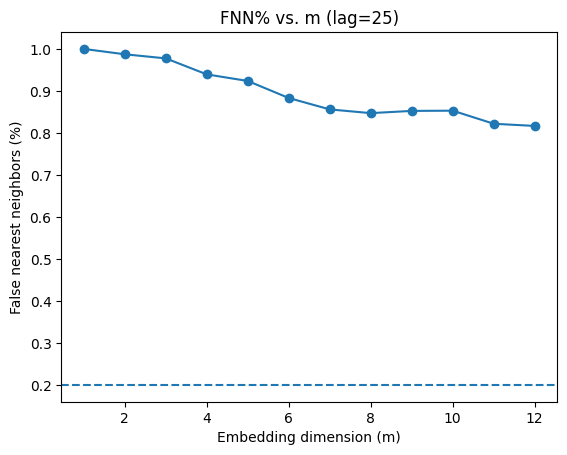

KeyboardInterrupt: 

In [61]:

def main():
    # specify path to your markers.nc
    from pathlib import Path
    import matplotlib.pyplot as plt
    cwd = Path.cwd()
    print("Current working directory:", cwd)
    file_path = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_13" /"Pre"/ "markers.nc"
    print("Resolved file path:       ", file_path.resolve())
    print("File exists?:             ", file_path.exists())
    # load and select COM
    ds = xr.open_dataset(file_path)
    da = ds["markers"] if "markers" in ds else ds
    com = da.sel(channel="COM")
    time = com.coords["time"].values  
    print("Time coordinates:", time[0], "to", time[-1])
    start_time = time[0]
    end_time = time[11000]
    com = com.sel(time=slice(start_time, end_time))  # select first 50 time points
    print("Selected COM shape:", start_time, end_time, com.shape)

    # parameters
    max_lag = 25
    bins = 64
    max_dim = 12
    rtol = 0.15
    fnn_threshold = 0.20
    fs = 100.0
    max_time = 10.0

    # process X and Z axes
    for axis in ["x", "z"]:
        ts = com.sel(axis=axis).values.ravel()
        ts = preprocess_signal(ts, fs)
        lag = optimal_lag(ts, max_lag=max_lag, bins=bins)
                # 1) Compute FNN% curve
        dims, fnn_perc = compute_fnn_percentage(ts, lag,
                                            max_dim=max_dim,
                                            rtol=rtol)

        # 2) Plot it
        plt.figure()
        plt.plot(dims, fnn_perc, '-o')
        plt.axhline(fnn_threshold, linestyle='--')
        plt.xlabel('Embedding dimension (m)')
        plt.ylabel('False nearest neighbors (%)')
        plt.title(f'FNN% vs. m (lag={lag})')
        plt.show()

        # 3) Now pick your embedding dim
        dim = optimal_embedding_dimension(ts, lag,
                                        max_dim=max_dim,
                                        rtol=rtol,
                                        fnn_threshold=fnn_threshold)


        lyap = compute_lyapunov_exponent(
            ts, emb_dim=dim, lag=lag,
            fs=fs, max_time=max_time
        )
        print(f"Axis {axis}: lag={lag}, dim={dim}, lyap={lyap:.4f}")

if __name__ == "__main__":
    main()

Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Resolved file path:        C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\data\CGA\03\markers+Com\5050602_20230814_SWS_1.3\markers.nc
File exists?:              True
Time coordinates: 1.22 to 114.05
Selected COM shape: (3, 11284)


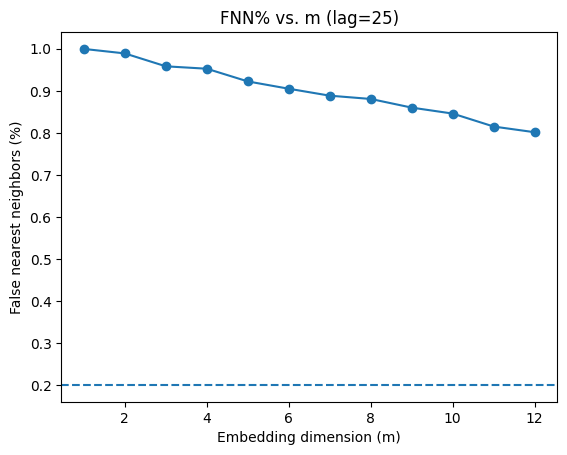

Axis x: lag=25, dim=12, lyap=0.4704


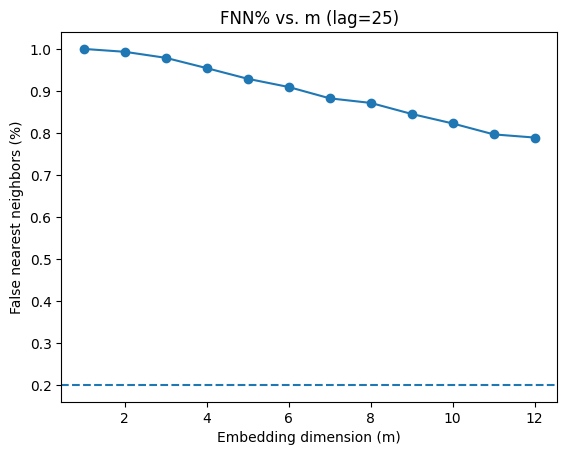

Axis z: lag=25, dim=12, lyap=0.4321


In [53]:

def main():
    # specify path to your markers.nc
    from pathlib import Path
    import matplotlib.pyplot as plt
    cwd = Path.cwd()
    print("Current working directory:", cwd)
    file_path = cwd.parent / "../data" / "CGA" / "03" / "markers+Com" /"5050602_20230814_SWS_1.3"/ "markers.nc"

    print("Resolved file path:       ", file_path.resolve())
    print("File exists?:             ", file_path.exists())
    # load and select COM
    ds = xr.open_dataset(file_path)
    da = ds["markers"] if "markers" in ds else ds
    com = da.sel(channel="COM")
    time = com.coords["time"].values  
    print("Time coordinates:", time[0], "to", time[-1])
    start_time = time[0]
    end_time = time[-1]
    com = com.sel(time=slice(start_time, end_time))  # select first 50 time points
    print("Selected COM shape:", com.shape)

    # parameters
    max_lag = 25
    bins = 64
    max_dim = 12
    rtol = 0.15
    fnn_threshold = 0.20
    fs = 100.0
    max_time = 10.0

    # process X and Z axes
    for axis in ["x", "z"]:
        ts = com.sel(axis=axis).values.ravel()
        ts = preprocess_signal(ts, fs)
        lag = optimal_lag(ts, max_lag=max_lag, bins=bins)
                # 1) Compute FNN% curve
        dims, fnn_perc = compute_fnn_percentage(ts, lag,
                                            max_dim=max_dim,
                                            rtol=rtol)

        # 2) Plot it
        plt.figure()
        plt.plot(dims, fnn_perc, '-o')
        plt.axhline(fnn_threshold, linestyle='--')
        plt.xlabel('Embedding dimension (m)')
        plt.ylabel('False nearest neighbors (%)')
        plt.title(f'FNN% vs. m (lag={lag})')
        plt.show()

        # 3) Now pick your embedding dim
        dim = optimal_embedding_dimension(ts, lag,
                                        max_dim=max_dim,
                                        rtol=rtol,
                                        fnn_threshold=fnn_threshold)


        lyap = compute_lyapunov_exponent(
            ts, emb_dim=dim, lag=lag,
            fs=fs, max_time=max_time
        )
        print(f"Axis {axis}: lag={lag}, dim={dim}, lyap={lyap:.4f}")

if __name__ == "__main__":
    main()

......

In [131]:
import numpy as np
import xarray as xr
from pathlib import Path
from scipy.signal import detrend, butter, filtfilt
import matplotlib.pyplot as plt


# 1) Preprocessing: detrend, band‐pass, and z‐score
def preprocess_signal(ts: np.ndarray,
                   fs: float = 100.0,
                   low_bp: float = 0.1,
                   high_bp: float = 5.0,
                   low_lp: float = 10.0,
                   do_zscore: bool = False) -> np.ndarray:
    """
    Preprocess a mediolateral COM (in mm) time series.
    
    Steps:
      1) Remove linear trend (detrend).
      2) Apply a gentle low-pass at `low_lp` Hz to remove >10 Hz noise.
      3) Apply a band-pass between `low_bp`–`high_bp` Hz to keep step frequency.
      4) Optionally zero-mean & unit-variance (z-score).
    
    Inputs:
      ts      : 1D np.ndarray of COM_x values in millimeters.
      fs      : Sampling frequency (default 100 Hz).
      low_bp  : Lower cutoff for band-pass (default 0.1 Hz).
      high_bp : Upper cutoff for band-pass (default 5.0 Hz).
      low_lp  : Cutoff for low-pass (default 10.0 Hz).
      do_zscore : If True, z-score the final output.
    
    Returns:
      ts_out  : Preprocessed 1D array, same length as input.
    """
    # 1) Detrend
    ts_dt = detrend(ts)

    # 2) Gentle low-pass at low_lp Hz
    nyq = fs / 2.0
    b_lp, a_lp = butter(N=4, Wn=(low_lp/nyq), btype='low')
    ts_lp = filtfilt(b_lp, a_lp, ts_dt)

    # 3) Band-pass from low_bp to high_bp Hz
    b_bp, a_bp = butter(N=4, Wn=[low_bp/nyq, high_bp/nyq], btype='bandpass')
    ts_bp = filtfilt(b_bp, a_bp, ts_lp)

    # 4) (Optional) Z-score
    if do_zscore:
        ts_out = (ts_bp - np.mean(ts_bp)) / np.std(ts_bp)
    else:
        ts_out = ts_bp

    return ts_out



# 2) Average Mutual Information with quantile bins
def average_mutual_information(ts: np.ndarray, lag: int, bins: int = 64) -> float:
    """
    Compute AMI I(lag) between x(t) and x(t+lag) using equal‐occupancy bins.
    """
    edges = np.quantile(ts, np.linspace(0, 1, bins+1))
    x, y = ts[:-lag], ts[lag:]
    hist2d, _, _ = np.histogram2d(x, y, bins=[edges, edges])
    pxy = hist2d / np.sum(hist2d)
    px = np.sum(pxy, axis=1)
    py = np.sum(pxy, axis=0)
    mask = pxy > 0
    return np.sum(pxy[mask] * np.log(pxy[mask] / (px[:, None] * py[None, :])[mask]))


# 3) Optimal lag: first local minimum of AMI or global minimum fallback
import numpy as np
import matplotlib.pyplot as plt

# def optimal_lag(ts: np.ndarray, max_lag: int = 50, bins: int = 64) -> int:
#     """
#     Find an “axis‐dependent” delay τ for embedding via Average Mutual Information (AMI).

#     1. Compute AMI(τ) for τ = 1…max_lag.
#     2. Plot AMI vs. τ for visual inspection.
#     3. Look for the first strict local minimum in that curve.
#     4. If none exists, look for the first τ where AMI(τ) < AMI(1)/e.
#     5. If still none, return the argmin of the entire AMI‐vector (global minimum).
#     """
#     # 1) Compute AMI for τ = 1…max_lag
#     ami_vals = [average_mutual_information(ts, lag, bins) for lag in range(1, max_lag + 1)]
#     lags = np.arange(1, max_lag + 1)

#     # 2) Plot AMI vs. τ
#     plt.figure()
#     plt.plot(lags, ami_vals, '-o', label='AMI')
#     plt.xlabel('Lag (samples)')
#     plt.ylabel('AMI')
#     plt.title('AMI vs. Lag')
#     plt.grid(True)
#     plt.legend()
#     plt.show()

#     # 3) Look for the first strict local minimum
#     for i in range(1, len(ami_vals) - 1):
#         if ami_vals[i] < ami_vals[i - 1] and ami_vals[i] < ami_vals[i + 1]:
#             return i + 1  # +1 because our list is 0-based but lags start at 1

#     # 4) Fallback #1: “1/e‐decay” rule, using AMI(1) as proxy for AMI(0)
#     threshold = ami_vals[0] / np.e
#     for i, val in enumerate(ami_vals):
#         if val < threshold:
#             return i + 1

#     # 5) Fallback #2: global minimum (should rarely be needed now)
#     return int(np.argmin(ami_vals) + 1)

import numpy as np
import matplotlib.pyplot as plt

# def optimal_lag(ts: np.ndarray, max_lag: int = 50, bins: int = 64) -> int:
#     """
#     Find an “axis‐dependent” delay τ for embedding via Average Mutual Information (AMI).

#     1) Compute AMI(τ) for τ = 1…max_lag.
#     2) Plot AMI vs. τ for visual inspection.
#     3) Try to pick the first *mild* local minimum, subject to a noise‐dip filter.
#        A “mild” local minimum means AMI[i] ≤ AMI[i−1] and AMI[i] ≤ AMI[i+1].
#        However, if that τ is very small (e.g. <5) and the drop is less than 5% of AMI(1),
#        we treat it as noise and skip forward.
#     4) If no acceptable mild local minimum, fallback: pick first τ where AMI(τ) ≤ AMI(1)/e.
#     5) If that still fails, return the global minimum (argmin).
#     """

#     # 1) Compute AMI for τ = 1…max_lag
#     ami_vals = [average_mutual_information(ts, lag, bins)
#                 for lag in range(1, max_lag + 1)]
#     lags = np.arange(1, max_lag + 1)

#     # 2) Plot AMI vs. τ, with AMI(1)/e for reference
#     plt.figure(figsize=(5, 3))
#     plt.plot(lags, ami_vals, '-o', label='AMI')
#     plt.axhline(ami_vals[0] / np.e, color='r', linestyle='--',
#                 label='AMI(1)/e')
#     plt.xlabel('Lag (samples)')
#     plt.ylabel('AMI')
#     plt.title('AMI vs. Lag')
#     plt.grid(True)
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

#     # 3) Look for first *mild* local minimum,
#     #    but ignore tiny “noise dips” at very small τ:
#     ami1 = ami_vals[0]
#     for i in range(1, len(ami_vals) - 1):
#         # mild condition: AMI[i] ≤ both immediate neighbors
#         if ami_vals[i] <= ami_vals[i - 1] and ami_vals[i] <= ami_vals[i + 1]:
#             τ_candidate = i + 1  # because ami_vals[0] is τ=1
#             # if that candidate τ is very small (<5), check drop size:
#             if τ_candidate < 5:
#                 # require that AMI drop at least 5% from AMI(1) to AMI(τ)
#                 if ami_vals[i] < 0.95 * ami1:
#                     return τ_candidate
#                 # else it’s too shallow—ignore it and continue searching
#                 continue
#             # otherwise, accept any mild local minimum at τ ≥ 5
#             return τ_candidate

#     # 4) Fallback #1: first τ where AMI(τ) ≤ AMI(1)/e
#     threshold = ami1 / np.e
#     for i, val in enumerate(ami_vals):
#         if val <= threshold:
#             return i + 1

#     # 5) Fallback #2: global minimum
#     return int(np.argmin(ami_vals) + 1)
import numpy as np
import matplotlib.pyplot as plt

# def optimal_lag(ts: np.ndarray, max_lag: int = 50, bins: int = 64) -> int:
#     """
#     Find a single, adaptive delay τ for embedding via Average Mutual Information (AMI),
#     suitable for both healthy and Parkinson's gait.

#     Steps:
#       1. Compute AMI(τ) for τ = 1…max_lag.
#       2. Plot AMI vs. τ with the AMI(1)/e threshold for visual check.
#       3. Search for the first “filtered mild local minimum”: AMI[i] ≤ neighbors AND
#          (AMI[i] ≤ 0.85·AMI(1) OR AMI[i] ≤ 0.90·AMI[i−1]).
#       4. If none found, look for the first τ where AMI(τ) ≤ AMI(1)/e.
#       5. If still none, return the global‐minimum lag.

#     Returns:
#       τ (int): Delay in samples (1…max_lag).
#     """
#     # 1) Compute AMI(τ=1…max_lag)
#     ami_vals = [average_mutual_information(ts, lag, bins)
#                 for lag in range(1, max_lag + 1)]
#     lags = np.arange(1, max_lag + 1)
#     ami1 = ami_vals[0]

#     # 2) Plot AMI vs. τ for debugging/visualization
#     plt.figure(figsize=(5, 3))
#     plt.plot(lags, ami_vals, '-o', label='AMI(τ)')
#     plt.axhline(ami1 / np.e, color='r', linestyle='--',
#                 label='AMI(1)/e')
#     plt.xlabel('Lag (samples)')
#     plt.ylabel('AMI')
#     plt.title('AMI vs. Lag')
#     plt.grid(True)
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

#     # 3) Search for the first “filtered mild local minimum”
#     #
#     #    Conditions for accepting a local minimum at index i (τ = i+1):
#     #      (a) AMI[i] <= AMI[i-1]  AND  AMI[i] <= AMI[i+1]
#     #      (b) [either AMI[i] <= 0.85*AMI(1)   OR   AMI[i] <= 0.90*AMI[i-1]]
#     #
#     #    Healthy subjects typically satisfy (b) via “AMI[i] <= 0.90*AMI[i-1]”
#     #    around τ ≈ 5–8. PD subjects satisfy (b) via “AMI[i] <= 0.85*AMI(1)”
#     #    only later, around τ ≈ 10–20, because their AMI decays slowly.
#     for i in range(1, len(ami_vals) - 1):
#         if (ami_vals[i] <= ami_vals[i - 1] 
#             and ami_vals[i] <= ami_vals[i + 1]):
#             # candidate local minimum at τ_candidate = i+1
#             if (ami_vals[i] <= 0.80 * ami1
#                or ami_vals[i] <= 0.90 * ami_vals[i - 1]):
#                 return i + 1

#     # 4) Fallback #1: first τ where AMI(τ) <= AMI(1)/e
#     threshold = ami1 / np.e
#     for i, val in enumerate(ami_vals):
#         if val <= threshold:
#             return i + 1

#     # # 5) Fallback #2: global minimum (very rarely used)
#     # return int(np.argmin(ami_vals) + 1)

import numpy as np
import matplotlib.pyplot as plt

def optimal_lag(ts: np.ndarray,
                fs: float = 100.0,
                max_lag: int = 50,
                bins: int = 64) -> int:
    """
    Find a single, adaptive delay τ for embedding via Average Mutual Information (AMI),
    suitable for both healthy and Parkinson's gait.

    Steps:
      1) Compute AMI(τ) for τ = 1…max_lag.
      2) Plot AMI vs. τ with the AMI(1)/e threshold for visual check.
      3) Search for the first “filtered mild local minimum,” but only up to τ ≤ 0.20·fs:
           • AMI[i] ≤ AMI[i−1]  AND  AMI[i] ≤ AMI[i+1]
           • AND (AMI[i] ≤ 0.80·AMI(1)   OR   AMI[i] ≤ 0.90·AMI[i−1])
        (This prevents the algorithm from choosing a very small τ unless AMI has already
         dropped by ≥ 20% of AMI(1).)
      4) If no acceptable knee appears by τ = ⌊0.20·fs⌋, fallback to the first τ ≤ ⌊0.20·fs⌋
         where AMI(τ) ≤ AMI(1)/e.
      5) If nothing qualifies by τ = ⌊0.20·fs⌋, return the global‐minimum lag over 1…max_lag.
    """
    # 1) Compute AMI for τ = 1…max_lag
    ami_vals = [average_mutual_information(ts, lag, bins)
                for lag in range(1, max_lag + 1)]
    lags = np.arange(1, max_lag + 1)
    ami1 = ami_vals[0]

    # 2) Plot AMI vs. τ (optional, but good to inspect)
    plt.figure(figsize=(5, 3))
    plt.plot(lags, ami_vals, '-o', label='AMI(τ)')
    plt.axhline(ami1 / np.e, color='r', linestyle='--', label='AMI(1)/e')
    plt.xlabel('Lag (samples)')
    plt.ylabel('AMI')
    plt.title('AMI vs. Lag')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3) Define a hard cutoff at τ_max = floor(0.20 * fs).  At 100 Hz, that is τ_max = 20.
    τ_max = min(max_lag, int(0.20 * fs))  # e.g. 20 if fs=100

    # If τ_max < 3 we can’t form a “local minimum” search, so just skip to fallback
    if τ_max < 3:
        return 1

    # 4) Look for the first “filtered mild local minimum” among τ = 2 … (τ_max - 1)
    #    (Indices i = 1 … (τ_max - 2) correspond to τ = i+1 = 2 … (τ_max-1))
    for i in range(1, τ_max - 1):  # i+1 ranges from 2 to τ_max-1
        if ami_vals[i] <= ami_vals[i - 1] and ami_vals[i] <= ami_vals[i + 1]:
            τ_candidate = i + 1  # because ami_vals[0] is τ=1
            # 4a) If τ_candidate is small (<5), only accept it if AMI has fallen by ≥20%
            if τ_candidate < 5:
                if ami_vals[i] <= 0.80 * ami1:
                    return τ_candidate
                else:
                    # Too shallow a drop at a very small τ—ignore it
                    continue
            # 4b) If τ_candidate ≥ 5, accept it unconditionally
            return τ_candidate

    # 5) Fallback #1: first τ ≤ τ_max where AMI(τ) ≤ AMI(1)/e
    threshold = ami1 / np.e
    for i in range(τ_max):  # i corresponds to τ = i+1
        if ami_vals[i] <= threshold:
            return i + 1

    # 6) Fallback #2: global minimum over τ = 1…max_lag
    return int(np.argmin(ami_vals) + 1)



# # 4) Compute false‐nearest‐neighbors percentage
# def compute_fnn_percentage(ts: np.ndarray, lag: int,
#                            max_dim: int = 20, rtol: float = 0.15):
#     """
#     Compute % of false nearest neighbors for embedding dims from 1 to max_dim.
#     """
#     N = len(ts)
#     dims = np.arange(1, max_dim+1)
#     fnn_perc = np.zeros_like(dims, dtype=float)

#     for idx, m in enumerate(dims):
#         M = N - m * lag
#         if M <= 0:
#             fnn_perc[idx:] = np.nan
#             break
#         # Build m-dimensional delay vectors
#         embedded = np.vstack([ts[i*lag : i*lag + M] for i in range(m)]).T
#         false = total = 0
#         for i in range(M):
#             # compute distances to all other points
#             dists = np.linalg.norm(embedded - embedded[i], axis=1)
#             dists[i] = np.inf
#             # exclude temporally too-close points
#             dists[max(0, i-m*lag): i + m*lag] = np.inf
#             j = np.argmin(dists)
#             if dists[j] == np.inf:
#                 continue
#             d_extra = abs(ts[i + m*lag] - ts[j + m*lag])
#             if d_extra / dists[j] > rtol:
#                 false += 1
#             total += 1
#         fnn_perc[idx] = false / total if total else np.nan

#     return dims, fnn_perc


# # 5) Optimal embedding dimension: first m with FNN% < threshold
# def optimal_embedding_dimension(ts: np.ndarray,
#                                 lag: int,
#                                 max_dim: int = 15,
#                                 rtol: float = 0.15,
#                                 fnn_threshold: float = 0.10) -> int:
#     """
#     Return the smallest m where FNN% < fnn_threshold,
#     else the 'elbow' where adding dims yields diminishing returns.
#     """
#     dims, fnn = compute_fnn_percentage(ts, lag, max_dim, rtol)
#     # threshold rule
#     for m, p in zip(dims, fnn):
#         if not np.isnan(p) and p < fnn_threshold:
#             return int(m)
#     # elbow‐fallback: look for the largest curvature point
#     # simple “maximum second‐difference” method
#     second_diff = np.diff(fnn, n=2)
#     if len(second_diff) > 0:
#         elbow = np.argmax(np.abs(second_diff)) + 2
#         return int(min(elbow, max_dim))
#     return max_dim

def compute_fnn_percentage(ts: np.ndarray, lag: int,
                           max_dim: int = 15, rtol: float = 0.15):
    """
    Compute % of false nearest neighbors for embedding dims from 1 to max_dim.
    """
    N = len(ts)
    dims = np.arange(1, max_dim + 1)
    fnn_perc = np.zeros_like(dims, dtype=float)

    for idx, m in enumerate(dims):
        M = N - m * lag
        if M <= 0:
            fnn_perc[idx:] = np.nan
            break
        # Build m-dimensional delay vectors
        embedded = np.vstack([ts[i * lag : i * lag + M] for i in range(m)]).T
        false = total = 0
        for i in range(M):
            # compute distances to all other points
            dists = np.linalg.norm(embedded - embedded[i], axis=1)
            dists[i] = np.inf
            # exclude temporally too-close points
            dists[max(0, i - m * lag) : i + m * lag] = np.inf
            j = np.argmin(dists)
            if dists[j] == np.inf:
                continue
            d_extra = abs(ts[i + m * lag] - ts[j + m * lag])
            if d_extra / dists[j] > rtol:
                false += 1
            total += 1
        fnn_perc[idx] = false / total if total else np.nan

    return dims, fnn_perc


# 5) Optimal embedding dimension by “elbow” / max second‐difference
def optimal_embedding_dimension(ts: np.ndarray,
                                lag: int,
                                max_dim: int = 15,
                                rtol: float = 0.15) -> int:
    """
    Choose embedding dimension m by finding the 'elbow' in the FNN% curve:
      1) Compute FNN% for m = 1…max_dim
      2) Take the second discrete difference of the fnn% array
      3) Return the dimension m corresponding to the index of maximal |second_difference|

    This follows the theoretical idea that the largest curvature (elbow) in the FNN% vs. m
    plot is the best embedding dimension when no fixed threshold is applied.
    """
    dims, fnn = compute_fnn_percentage(ts, lag, max_dim, rtol)

    # If there's only one dimension or fnn cannot be computed, just return max_dim
    if len(dims) < 3 or np.all(np.isnan(fnn)):
        return max_dim

    # Compute second discrete difference of the FNN% curve
    # second_diff[i] = fnn[i] - 2*fnn[i+1] + fnn[i+2], where i = 0..(len(fnn)-3)
    second_diff = np.diff(fnn, n=2)

    # If all second_diff are NaN or zero, fallback to max_dim
    if np.all(np.isnan(second_diff)) or np.allclose(second_diff, 0, equal_nan=True):
        return max_dim

    # Find the index of maximum absolute curvature
    # Since second_diff is length (max_dim - 2), its index i corresponds to m = i + 2
    i_elbow = int(np.nanargmax(np.abs(second_diff)))
    m_elbow = i_elbow + 2

    # Ensure we do not exceed max_dim
    if m_elbow < 1:
        return 1
    if m_elbow > max_dim:
        return max_dim
    return m_elbow




# 6) Rosenstein's λ_max with linear‐region fit (0.1–0.5 s)
def compute_lyapunov_exponent(ts: np.ndarray, emb_dim: int, lag: int,
                              fs: float = 100.0, max_time: float = 5.0) -> float:
    """
    Compute short‐term Lyapunov exponent λ* by tracking divergence of nearest neighbors.
    Fit ⟨ln d(t)⟩ vs. t over 0.1–0.5 s.
    """
    N = len(ts)
    M = N - (emb_dim - 1) * lag
    if M <= 0:
        return np.nan

    embedded = np.vstack([ts[i * lag : i * lag + M] for i in range(emb_dim)]).T
    min_sep = emb_dim * lag
    divergence = []

    for i in range(M):
        dists = np.linalg.norm(embedded - embedded[i], axis=1)
        dists[i] = np.inf
        dists[max(0, i - min_sep) : i + min_sep] = np.inf
        j = np.argmin(dists)
        if dists[j] == np.inf:
            continue

        k_max = min(M - i, M - j, int(max_time * fs))
        for k in range(1, k_max):
            d = np.linalg.norm(embedded[i + k] - embedded[j + k])
            if d > 0:
                divergence.append((k / fs, np.log(d)))

    if not divergence:
        return np.nan

    data = np.array(divergence)
    times, logs = data[:, 0], data[:, 1]

    # Bin and average
    bins = np.linspace(0, max_time, 50)
    centers, means = [], []
    for b in range(len(bins) - 1):
        mask = (times >= bins[b]) & (times < bins[b + 1])
        if mask.any():
            centers.append((bins[b] + bins[b + 1]) / 2)
            means.append(logs[mask].mean())

    centers = np.array(centers)
    means = np.array(means)

    # Plot divergence curve for inspection
    plt.figure()
    plt.plot(centers, means, 'o-')
    plt.axvline(0.1, color='r', linestyle='--', label='0.1 s')
    plt.axvline(0.5, color='r', linestyle='--', label='0.5 s')
    plt.xlabel('Time (s)')
    plt.ylabel('Average ln(distance)')
    plt.title('Divergence curve')
    plt.grid(True)
    plt.legend()
    plt.show()

    # Fit only over 0.1–0.5 s
    fit_mask = (centers >= 0.1) & (centers <= 0.5)
    if fit_mask.sum() < 2:
        return np.nan

    slope, _ = np.polyfit(centers[fit_mask], means[fit_mask], 1)
    return slope


Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Resolved file path:        C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\data\PBT\Young\Cereneo_SR_13\Pre.3\markers.nc
File exists?:              True
Time coordinates: 11.08 to 288.34999999999997
Selected COM shape: 11.08 121.07999999999998 (3, 11001)


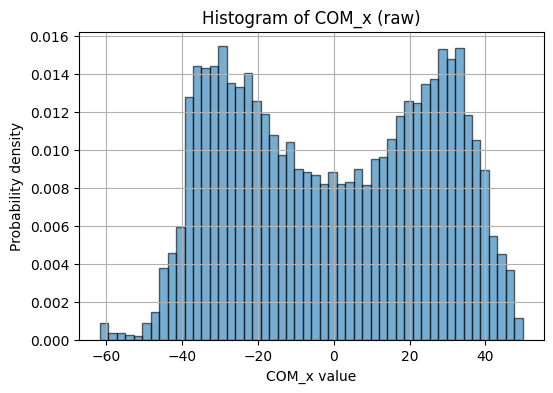

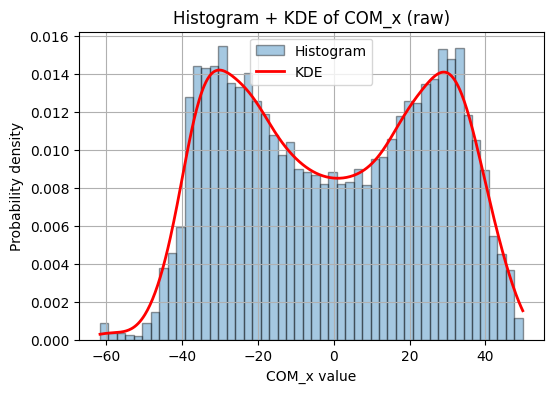

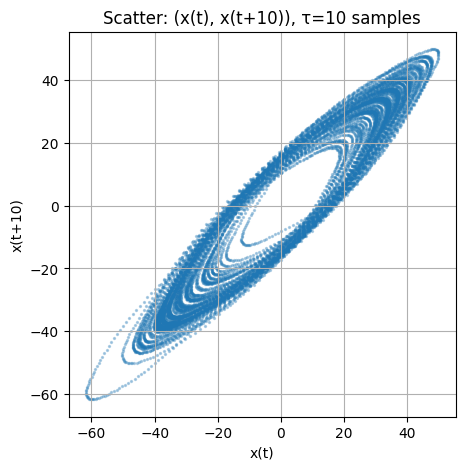

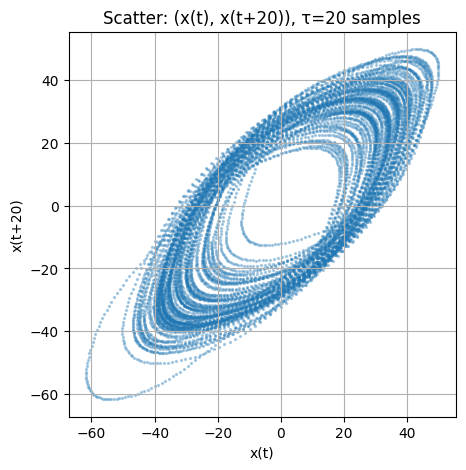

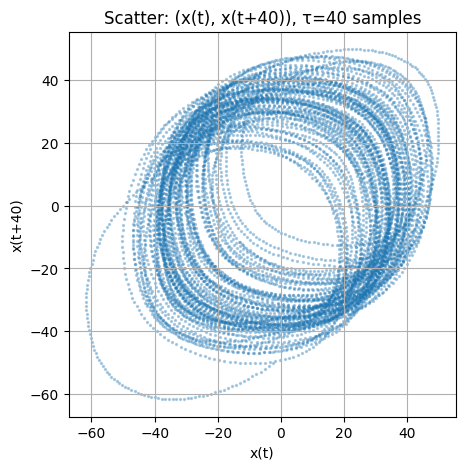

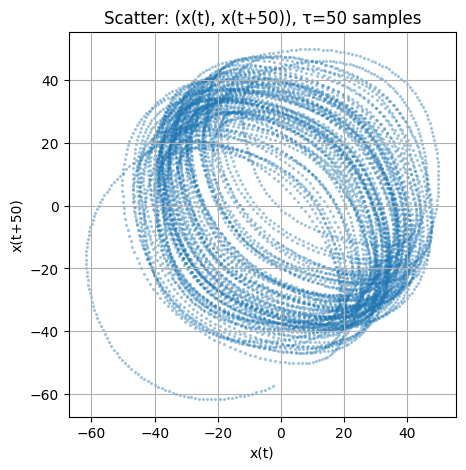

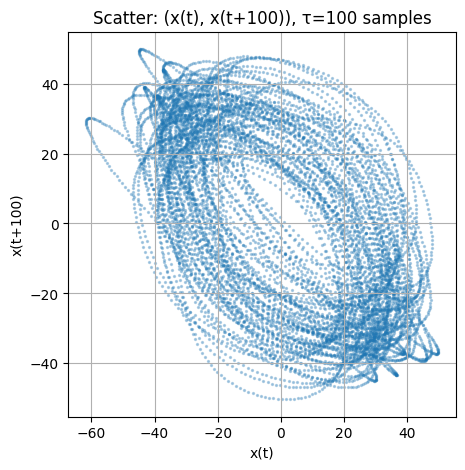


--- Axis: x ---


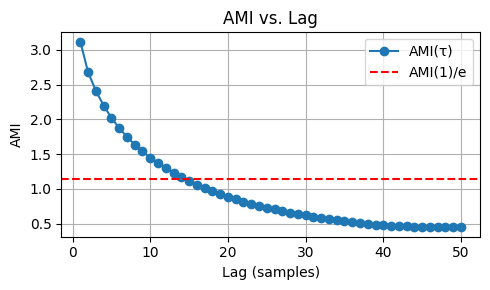

Optimal lag (τ) for axis x: 15 samples (0.150 s)


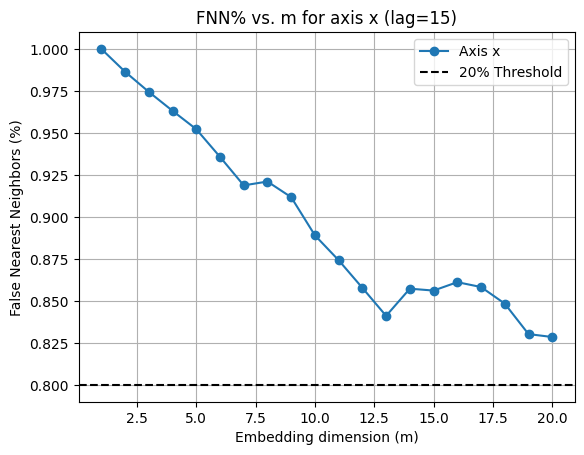

Optimal embedding dimension (m) for axis x: 13


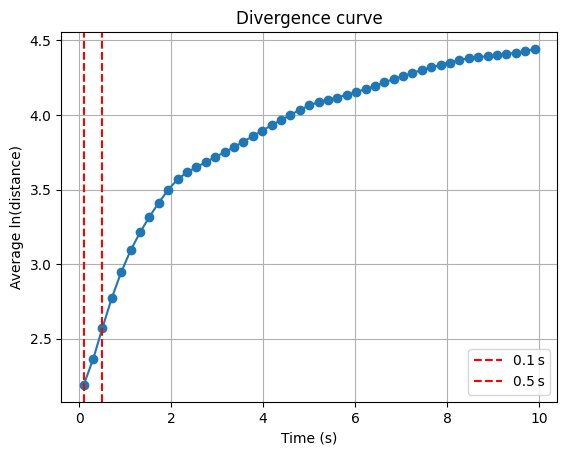

Lyapunov exponent (λ*) for axis x: 0.8407 1/s

--- Axis: z ---


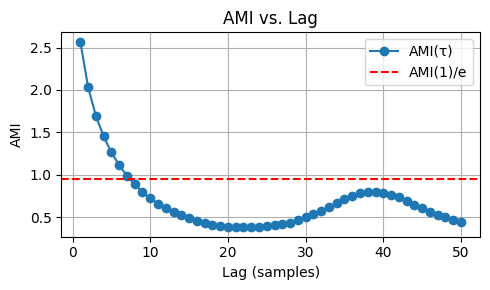

Optimal lag (τ) for axis z: 8 samples (0.080 s)


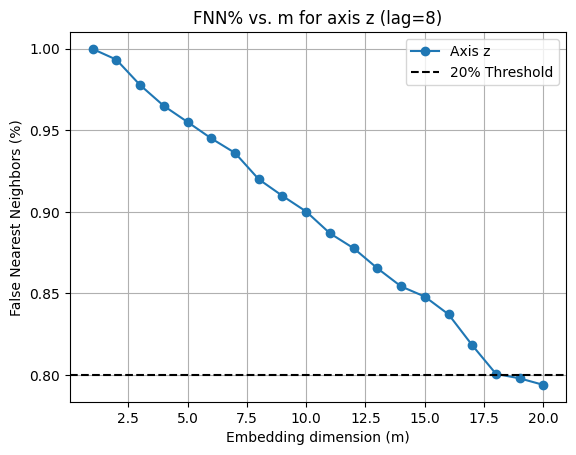

Optimal embedding dimension (m) for axis z: 18


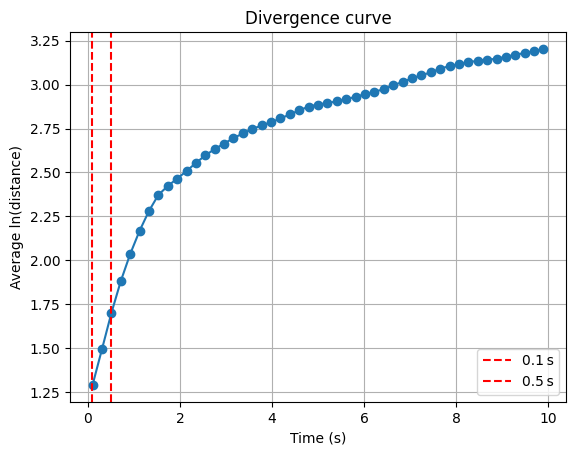

Lyapunov exponent (λ*) for axis z: 0.9942 1/s


In [133]:


def main():
    from pathlib import Path
    import matplotlib.pyplot as plt
    cwd = Path.cwd()
    print("Current working directory:", cwd)
    file_path = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_13" /"Pre.3"/ "markers.nc"
    print("Resolved file path:       ", file_path.resolve())
    print("File exists?:             ", file_path.exists())
    # load and select COM
    ds = xr.open_dataset(file_path)
    da = ds["markers"] if "markers" in ds else ds
    com = da.sel(channel="COM")
    time = com.coords["time"].values  
    print("Time coordinates:", time[0], "to", time[-1])
    start_time = time[0]
    end_time = time[11000]
    com = com.sel(time=slice(start_time, end_time))  # select first 50 time points
    print("Selected COM shape:", start_time, end_time, com.shape)

    # ------------- Parameters -------------
    max_lag = 50        # Search AMI up to 50 samples (0.50 s)
    bins = 64
    max_dim = 20        # Search FNN% up to 20 dimensions
    rtol = 0.10
    fnn_threshold = 0.80
    fs = 100.0
    max_time = 10.0     # Max evolution time for divergence (s)
    import numpy as np
    import matplotlib.pyplot as plt

    # Assume ts_raw is your raw (detrended/unfiltered) COM_x array of length N:
    ts_x= com.sel(axis='x').values.ravel()
    ts_x=preprocess_signal(ts_x, fs)  # Preprocess the signal
    # 1a) Simple histogram
    plt.figure(figsize=(6, 4))
    plt.hist(ts_x, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel('COM_x value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM_x (raw)')
    plt.grid(True)
    plt.show()

    # 1b) Optionally, a smoothed kernel‐density estimate (if you have seaborn, or use scipy)
    from scipy.stats import gaussian_kde

    kde = gaussian_kde(ts_x)              # fit a Gaussian kernel density
    xs = np.linspace(ts_x.min(), ts_x.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_x, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs, kde(xs), 'r-', lw=2, label='KDE')
    plt.xlabel('COM_x value')
    plt.ylabel('Probability density')
    plt.title('Histogram + KDE of COM_x (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # ts_raw is your raw (detrended but unfiltered) COM_x array
    ts_raw = com.sel(axis='x').values.ravel()
    ts_raw = preprocess_signal(ts_raw, fs)  # Preprocess the signal
    for tau in [10, 20,40,50,100]:  # try a few small lags
        x1 = ts_raw[:-tau]   # x(t)
        x2 = ts_raw[tau:]    # x(t + tau)

        plt.figure(figsize=(5,5))
        plt.scatter(x1, x2, s=2, alpha=0.3)
        plt.xlabel(f'x(t)')
        plt.ylabel(f'x(t+{tau})')
        plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
        plt.grid(True)
        plt.show()



    # ------------- Process each axis separately -------------
    for axis in ["x", "z"]:
        print(f"\n--- Axis: {axis} ---")
        ts = com.sel(axis=axis).values.ravel()

        # 1) Preprocess (detrend + 0.1–3 Hz bandpass + z-score)
        ts = preprocess_signal(ts, fs)

        # 2) Find axis-specific optimal lag via AMI
        lag = optimal_lag(ts, max_lag=max_lag, bins=bins)
        print(f"Optimal lag (τ) for axis {axis}: {lag} samples ({lag/fs:.3f} s)")

        # 3) Compute FNN% up to max_dim
        dims, fnn_perc = compute_fnn_percentage(ts, lag, max_dim=max_dim, rtol=rtol)

        # 4) Plot FNN% vs. embedding dimension
        plt.figure()
        plt.plot(dims, fnn_perc, "-o", label=f"Axis {axis}")
        plt.axhline(fnn_threshold, linestyle="--", color="k", label="20% Threshold")
        plt.xlabel("Embedding dimension (m)")
        plt.ylabel("False Nearest Neighbors (%)")
        plt.title(f"FNN% vs. m for axis {axis} (lag={lag})")
        plt.grid(True)
        plt.legend()
        plt.show()

        # 5) Find axis-specific embedding dimension
        dim = optimal_embedding_dimension(
            ts, lag, max_dim=max_dim, rtol=rtol
        )
        print(f"Optimal embedding dimension (m) for axis {axis}: {dim}")

        # 6) Compute Lyapunov exponent for this axis
        lyap = compute_lyapunov_exponent(ts, emb_dim=dim, lag=lag, fs=fs, max_time=max_time)
        print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap:.4f} 1/s")


if __name__ == "__main__":
    main()

Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Resolved file path:        C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\data\CGA\03\markers+Com\5050602_20230620_PWS_with.3\markers.nc
File exists?:              True
Time coordinates: 0.13 to 93.00999999999999
Selected COM shape: 0.13 93.00999999999999 (3, 9289)


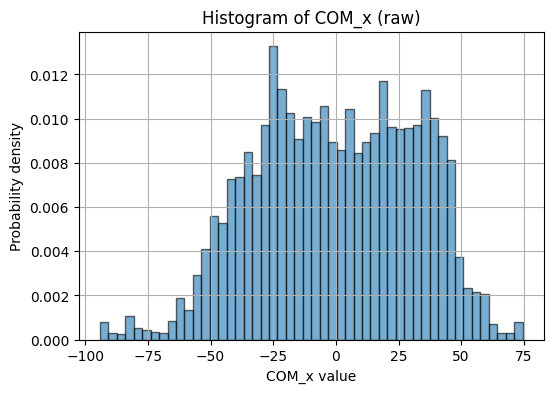

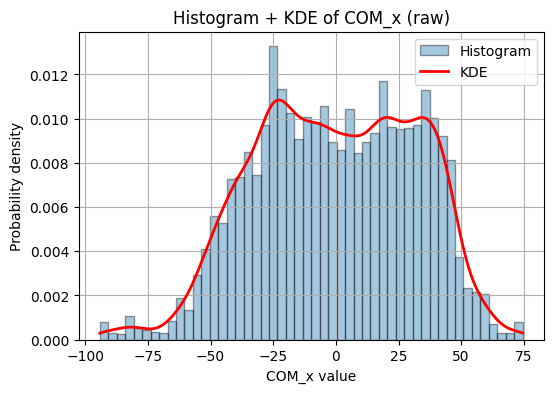

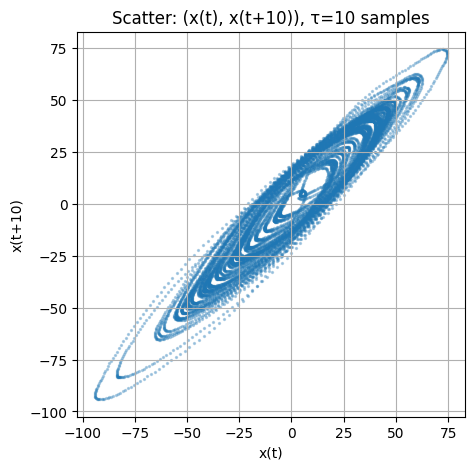

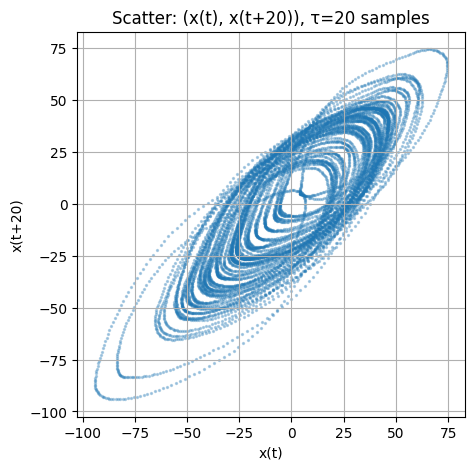

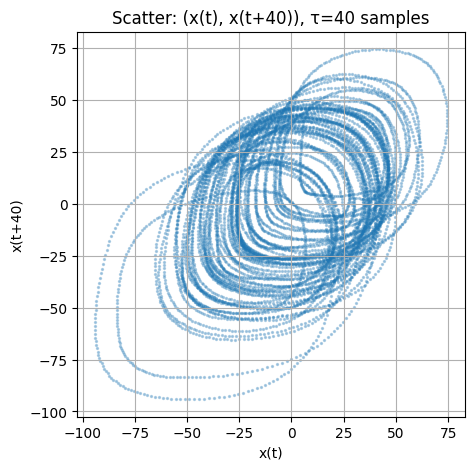

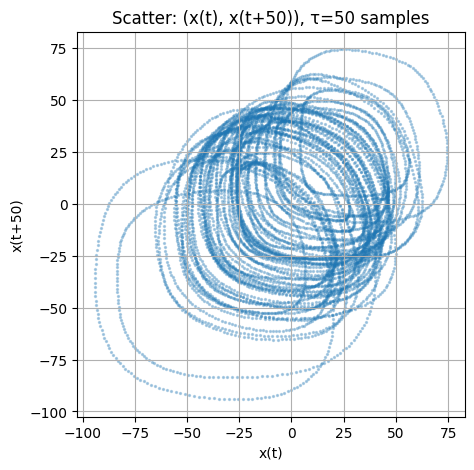

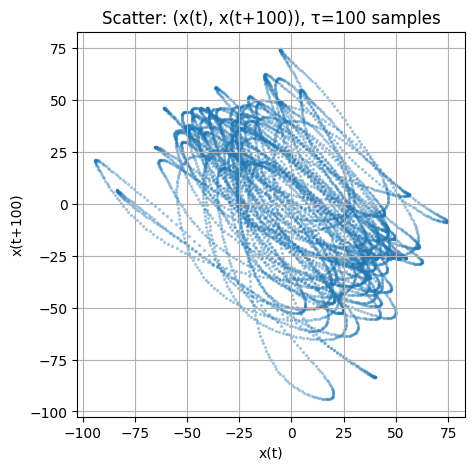


--- Axis: x ---


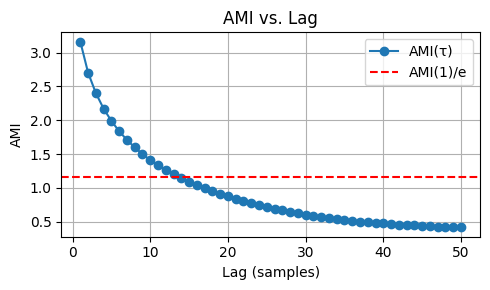

Optimal lag (τ) for axis x: 14 samples (0.140 s)


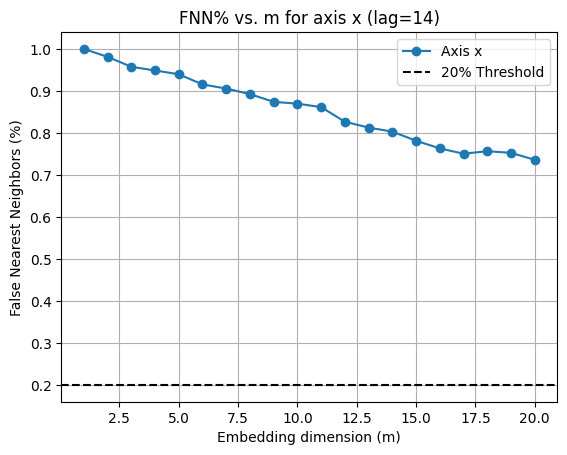

Optimal embedding dimension (m) for axis x: 11


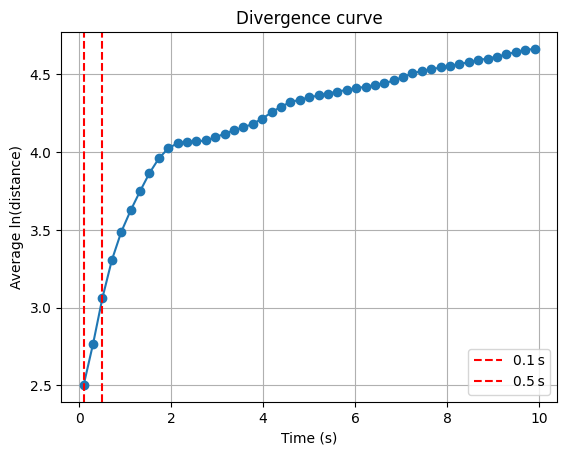

Lyapunov exponent (λ*) for axis x: 1.2985 1/s

--- Axis: z ---


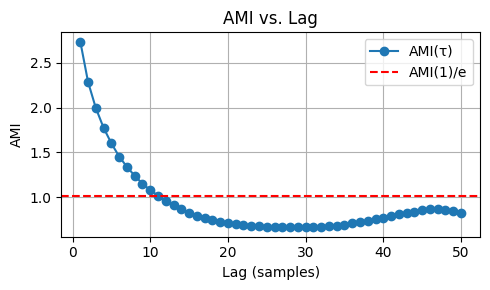

Optimal lag (τ) for axis z: 12 samples (0.120 s)


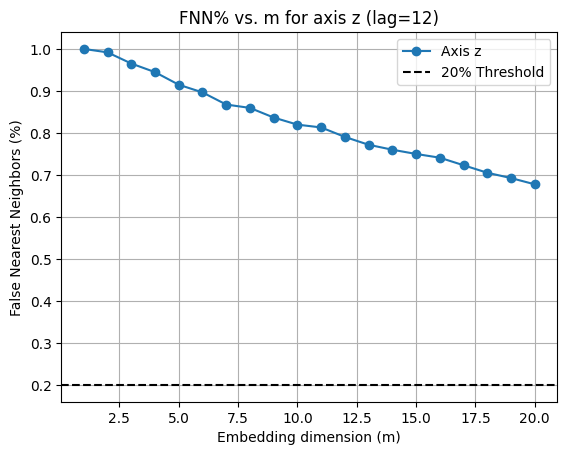

Optimal embedding dimension (m) for axis z: 7


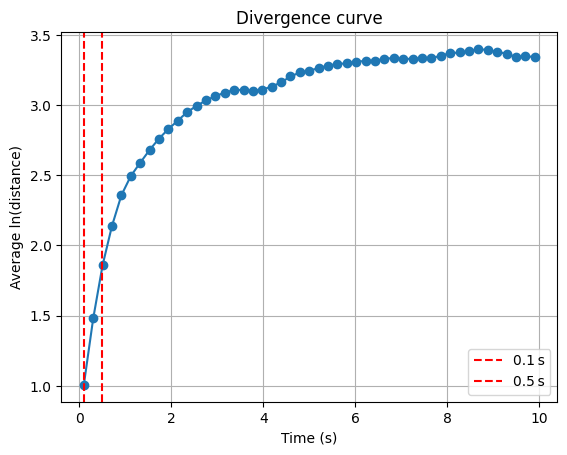

Lyapunov exponent (λ*) for axis z: 2.3223 1/s


In [134]:


def main():
    from pathlib import Path
    import matplotlib.pyplot as plt
    cwd = Path.cwd()
    print("Current working directory:", cwd)
    file_path = cwd.parent /"../data" / "CGA" / "03" / "markers+Com" /"5050602_20230620_PWS_with.3"/ "markers.nc"
    print("Resolved file path:       ", file_path.resolve())
    print("File exists?:             ", file_path.exists())
    # load and select COM
    ds = xr.open_dataset(file_path)
    da = ds["markers"] if "markers" in ds else ds
    com = da.sel(channel="COM")
    time = com.coords["time"].values  
    print("Time coordinates:", time[0], "to", time[-1])
    start_time = time[0]
    end_time = time[-1]
    com = com.sel(time=slice(start_time, end_time))  # select first 50 time points
    print("Selected COM shape:", start_time, end_time, com.shape)

    # ------------- Parameters -------------
    max_lag = 50        # Search AMI up to 50 samples (0.50 s)
    bins = 64
    max_dim = 20        # Search FNN% up to 20 dimensions
    rtol = 0.15
    fnn_threshold = 0.20
    fs = 100.0
    max_time = 10.0     # Max evolution time for divergence (s)
    import numpy as np
    import matplotlib.pyplot as plt

    # Assume ts_raw is your raw (detrended/unfiltered) COM_x array of length N:
    ts_x= com.sel(axis='x').values.ravel()
    ts_x=preprocess_signal(ts_x, fs)  # Preprocess the signal
    # 1a) Simple histogram
    plt.figure(figsize=(6, 4))
    plt.hist(ts_x, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel('COM_x value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM_x (raw)')
    plt.grid(True)
    plt.show()

    # 1b) Optionally, a smoothed kernel‐density estimate (if you have seaborn, or use scipy)
    from scipy.stats import gaussian_kde

    kde = gaussian_kde(ts_x)              # fit a Gaussian kernel density
    xs = np.linspace(ts_x.min(), ts_x.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_x, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs, kde(xs), 'r-', lw=2, label='KDE')
    plt.xlabel('COM_x value')
    plt.ylabel('Probability density')
    plt.title('Histogram + KDE of COM_x (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # ts_raw is your raw (detrended but unfiltered) COM_x array
    ts_raw = com.sel(axis='x').values.ravel()
    ts_raw = preprocess_signal(ts_raw, fs)  # Preprocess the signal
    for tau in [10, 20,40,50,100]:  # try a few small lags
        x1 = ts_raw[:-tau]   # x(t)
        x2 = ts_raw[tau:]    # x(t + tau)

        plt.figure(figsize=(5,5))
        plt.scatter(x1, x2, s=2, alpha=0.3)
        plt.xlabel(f'x(t)')
        plt.ylabel(f'x(t+{tau})')
        plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
        plt.grid(True)
        plt.show()



    # ------------- Process each axis separately -------------
    for axis in ["x", "z"]:
        print(f"\n--- Axis: {axis} ---")
        ts = com.sel(axis=axis).values.ravel()

        # 1) Preprocess (detrend + 0.1–3 Hz bandpass + z-score)
        ts = preprocess_signal(ts, fs)

        # 2) Find axis-specific optimal lag via AMI
        lag = optimal_lag(ts, max_lag=max_lag, bins=bins)
        print(f"Optimal lag (τ) for axis {axis}: {lag} samples ({lag/fs:.3f} s)")

        # 3) Compute FNN% up to max_dim
        dims, fnn_perc = compute_fnn_percentage(ts, lag, max_dim=max_dim, rtol=rtol)

        # 4) Plot FNN% vs. embedding dimension
        plt.figure()
        plt.plot(dims, fnn_perc, "-o", label=f"Axis {axis}")
        plt.axhline(fnn_threshold, linestyle="--", color="k", label="20% Threshold")
        plt.xlabel("Embedding dimension (m)")
        plt.ylabel("False Nearest Neighbors (%)")
        plt.title(f"FNN% vs. m for axis {axis} (lag={lag})")
        plt.grid(True)
        plt.legend()
        plt.show()

        # 5) Find axis-specific embedding dimension
        dim = optimal_embedding_dimension(
            ts, lag, max_dim=max_dim, rtol=rtol
        )
        print(f"Optimal embedding dimension (m) for axis {axis}: {dim}")

        # 6) Compute Lyapunov exponent for this axis
        lyap = compute_lyapunov_exponent(ts, emb_dim=dim, lag=lag, fs=fs, max_time=max_time)
        print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap:.4f} 1/s")


if __name__ == "__main__":
    main()

Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Resolved file path:        C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\data\CGA\03\markers+Com\5050602_20231230_SWS.3\markers.nc
File exists?:              True
Time coordinates: 0.13 to 115.36
Selected COM shape: 0.13 115.36 (3, 11524)


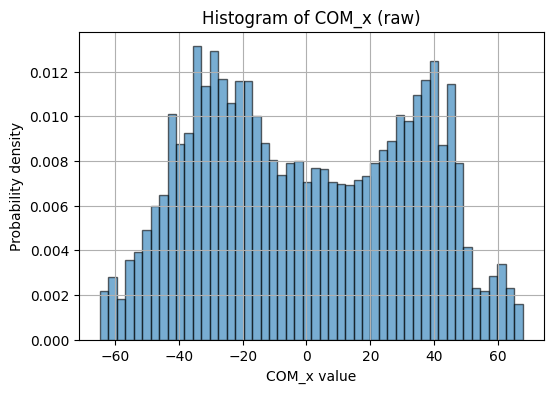

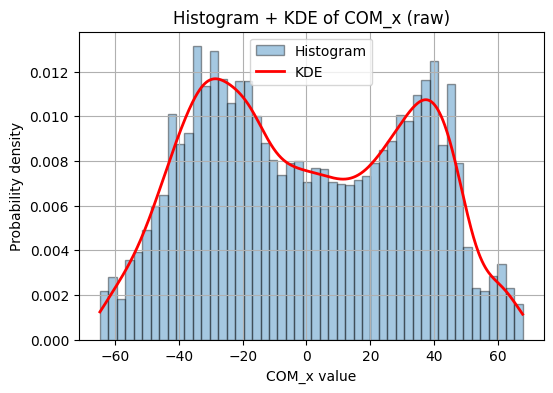

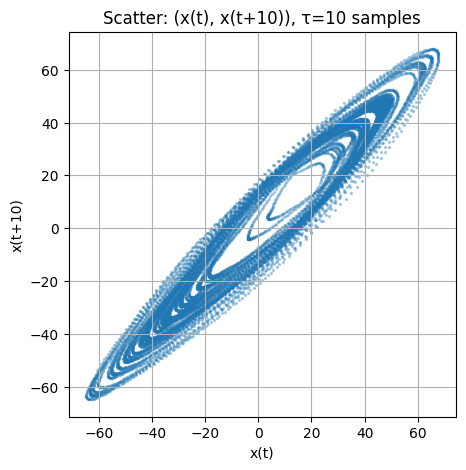

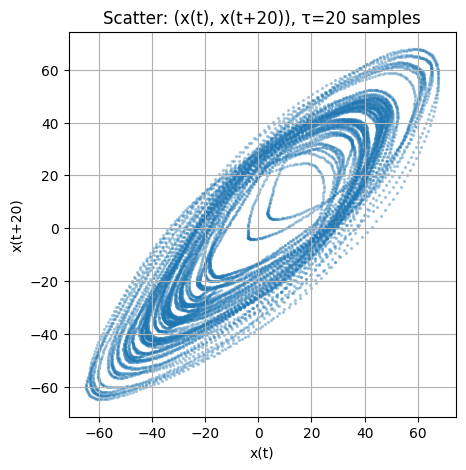

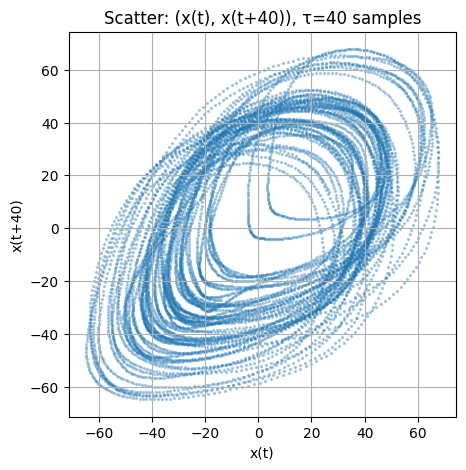

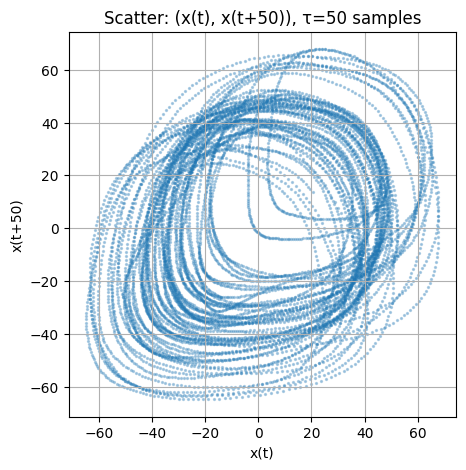

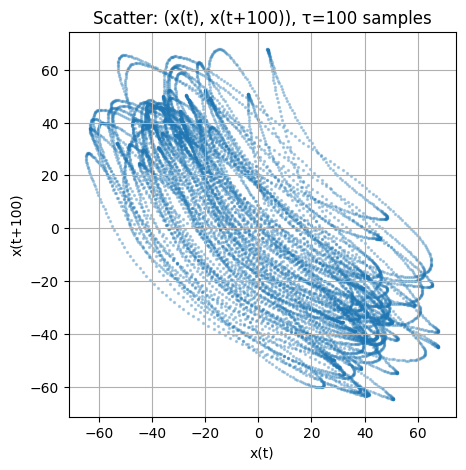


--- Axis: x ---


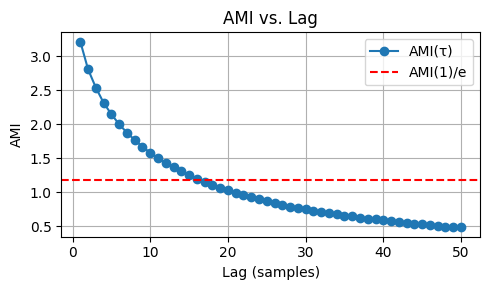

Optimal lag (τ) for axis x: 17 samples (0.170 s)


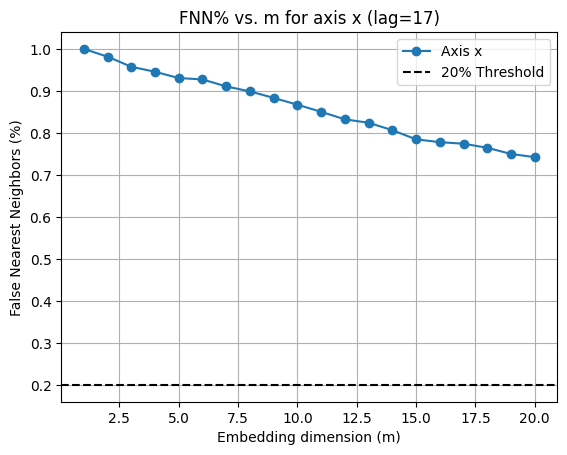

Optimal embedding dimension (m) for axis x: 15


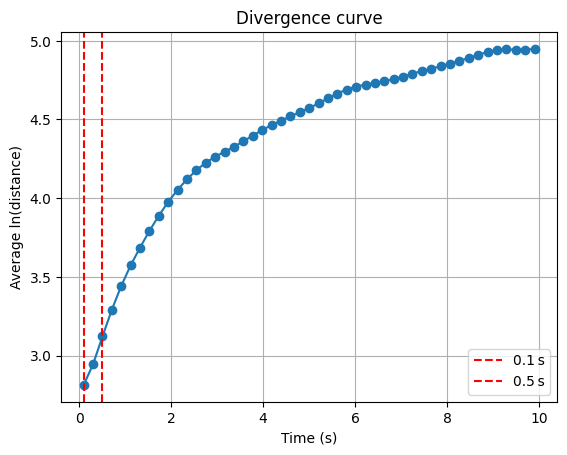

Lyapunov exponent (λ*) for axis x: 0.6469 1/s

--- Axis: z ---


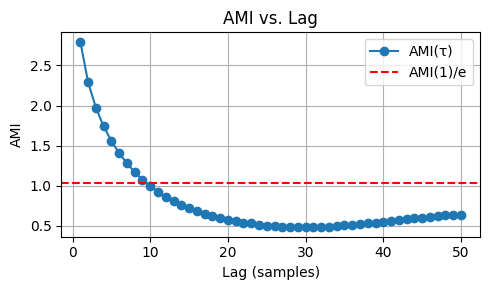

Optimal lag (τ) for axis z: 10 samples (0.100 s)


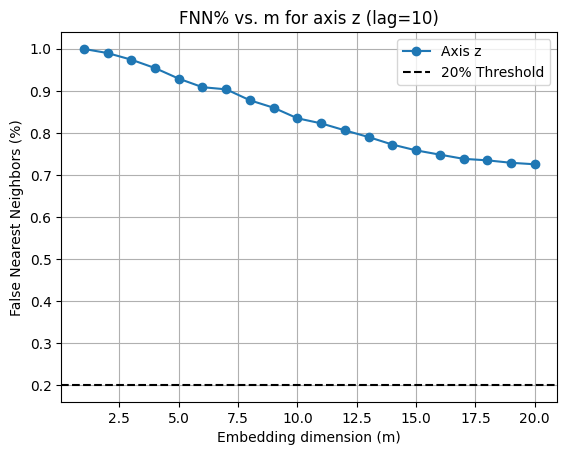

Optimal embedding dimension (m) for axis z: 7


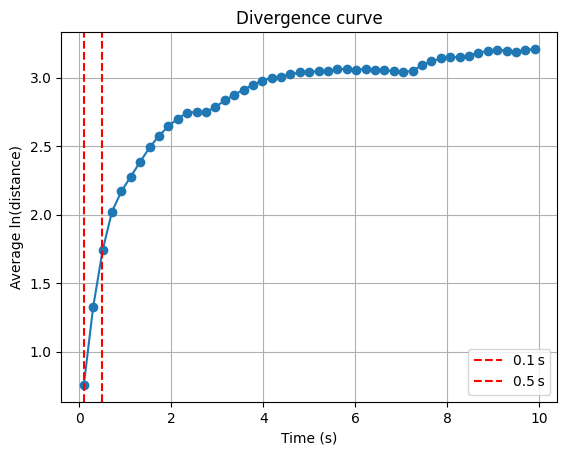

Lyapunov exponent (λ*) for axis z: 2.7979 1/s


In [135]:


def main():
    from pathlib import Path
    import matplotlib.pyplot as plt
    cwd = Path.cwd()
    print("Current working directory:", cwd)
    file_path = cwd.parent /"../data" / "CGA" / "03" / "markers+Com" /"5050602_20231230_SWS.3"/ "markers.nc"
    print("Resolved file path:       ", file_path.resolve())
    print("File exists?:             ", file_path.exists())
    # load and select COM
    ds = xr.open_dataset(file_path)
    da = ds["markers"] if "markers" in ds else ds
    com = da.sel(channel="COM")
    time = com.coords["time"].values  
    print("Time coordinates:", time[0], "to", time[-1])
    start_time = time[0]
    end_time = time[-1]
    com = com.sel(time=slice(start_time, end_time))  # select first 50 time points
    print("Selected COM shape:", start_time, end_time, com.shape)

    # ------------- Parameters -------------
    max_lag = 50        # Search AMI up to 50 samples (0.50 s)
    bins = 64
    max_dim = 20        # Search FNN% up to 20 dimensions
    rtol = 0.15
    fnn_threshold = 0.20
    fs = 100.0
    max_time = 10.0     # Max evolution time for divergence (s)
    import numpy as np
    import matplotlib.pyplot as plt

    # Assume ts_raw is your raw (detrended/unfiltered) COM_x array of length N:
    ts_x= com.sel(axis='x').values.ravel()
    ts_x=preprocess_signal(ts_x, fs)  # Preprocess the signal
    # 1a) Simple histogram
    plt.figure(figsize=(6, 4))
    plt.hist(ts_x, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel('COM_x value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM_x (raw)')
    plt.grid(True)
    plt.show()

    # 1b) Optionally, a smoothed kernel‐density estimate (if you have seaborn, or use scipy)
    from scipy.stats import gaussian_kde

    kde = gaussian_kde(ts_x)              # fit a Gaussian kernel density
    xs = np.linspace(ts_x.min(), ts_x.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_x, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs, kde(xs), 'r-', lw=2, label='KDE')
    plt.xlabel('COM_x value')
    plt.ylabel('Probability density')
    plt.title('Histogram + KDE of COM_x (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # ts_raw is your raw (detrended but unfiltered) COM_x array
    ts_raw = com.sel(axis='x').values.ravel()
    ts_raw = preprocess_signal(ts_raw, fs)  # Preprocess the signal
    for tau in [10, 20,40,50,100]:  # try a few small lags
        x1 = ts_raw[:-tau]   # x(t)
        x2 = ts_raw[tau:]    # x(t + tau)

        plt.figure(figsize=(5,5))
        plt.scatter(x1, x2, s=2, alpha=0.3)
        plt.xlabel(f'x(t)')
        plt.ylabel(f'x(t+{tau})')
        plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
        plt.grid(True)
        plt.show()



    # ------------- Process each axis separately -------------
    for axis in ["x", "z"]:
        print(f"\n--- Axis: {axis} ---")
        ts = com.sel(axis=axis).values.ravel()

        # 1) Preprocess (detrend + 0.1–3 Hz bandpass + z-score)
        ts = preprocess_signal(ts, fs)

        # 2) Find axis-specific optimal lag via AMI
        lag = optimal_lag(ts, max_lag=max_lag, bins=bins)
        print(f"Optimal lag (τ) for axis {axis}: {lag} samples ({lag/fs:.3f} s)")

        # 3) Compute FNN% up to max_dim
        dims, fnn_perc = compute_fnn_percentage(ts, lag, max_dim=max_dim, rtol=rtol)

        # 4) Plot FNN% vs. embedding dimension
        plt.figure()
        plt.plot(dims, fnn_perc, "-o", label=f"Axis {axis}")
        plt.axhline(fnn_threshold, linestyle="--", color="k", label="20% Threshold")
        plt.xlabel("Embedding dimension (m)")
        plt.ylabel("False Nearest Neighbors (%)")
        plt.title(f"FNN% vs. m for axis {axis} (lag={lag})")
        plt.grid(True)
        plt.legend()
        plt.show()

        # 5) Find axis-specific embedding dimension
        dim = optimal_embedding_dimension(
            ts, lag, max_dim=max_dim, rtol=rtol
        )
        print(f"Optimal embedding dimension (m) for axis {axis}: {dim}")

        # 6) Compute Lyapunov exponent for this axis
        lyap = compute_lyapunov_exponent(ts, emb_dim=dim, lag=lag, fs=fs, max_time=max_time)
        print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap:.4f} 1/s")


if __name__ == "__main__":
    main()